In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("manufacturing_production_data.csv")

# TASK 1: DATA EXPLORATION

## STRUCTURE OVERVIEW

### TO SHOW TOTAL ROWS AND COLUMNS

In [3]:
df.shape

(1000, 20)

In [4]:
df.head(5)


,Production ID,Production Date,Factory,Production Line,Shift,Machine ID,Machine Type,Operator ID,Product Category,Planned Production,Actual Production,Defective Units,Downtime (Minutes),Production Hours,Energy Consumption (kWh),Maintenance Cost ($),Unit Production Cost ($),Temperature (°C),Humidity (%),Quality Inspection Score
0,P00001,2025-05-21,Factory A,Line B,Morning,M107,Manual,OP1095,Air Conditioner,237,249,2,75.0,12,332,171.51,117.92,28.1,36,82.4
1,P00002,2025-04-23,Factory B,Line C,Morning,M111,Manual,OP1055,Washing Machine,459,421,17,19.0,9,1081,907.83,64.42,19.9,57,84.1
2,P00003,2025-10-02,Factory A,Line D,Morning,M136,Semi-Automatic,OP1081,Air Conditioner,202,159,5,73.0,9,1021,266.93,306.04,33.5,40,94.2
3,P00004,2025-05-23,Factory B,Line C,Morning,M124,Semi-Automatic,OP1027,Washing Machine,231,198,2,77.0,9,846,1849.90,94.45,25.6,75,87.5
4,P00005,2025-01-29,Factory A,Line A,Afternoon,M126,Semi-Automatic,OP1009,Television,292,266,18,112.0,10,517,1673.05,193.14,36.3,64,65.7


### SHOWS DTYPES AND NON NULL COUNT

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Production ID             1000 non-null   object 
 1   Production Date           1000 non-null   object 
 2   Factory                   1000 non-null   object 
 3   Production Line           1000 non-null   object 
 4   Shift                     1000 non-null   object 
 5   Machine ID                1000 non-null   object 
 6   Machine Type              1000 non-null   object 
 7   Operator ID               1000 non-null   object 
 8   Product Category          1000 non-null   object 
 9   Planned Production        1000 non-null   int64  
 10  Actual Production         1000 non-null   int64  
 11  Defective Units           1000 non-null   int64  
 12  Downtime (Minutes)        985 non-null    float64
 13  Production Hours          1000 non-null   int64  
 14  Energy Co

In [6]:
df.dtypes

Production ID                object
Production Date              object
Factory                      object
Production Line              object
Shift                        object
Machine ID                   object
Machine Type                 object
Operator ID                  object
Product Category             object
Planned Production            int64
Actual Production             int64
Defective Units               int64
Downtime (Minutes)          float64
Production Hours              int64
Energy Consumption (kWh)      int64
Maintenance Cost ($)        float64
Unit Production Cost ($)    float64
Temperature (°C)            float64
Humidity (%)                  int64
Quality Inspection Score    float64
dtype: object

## DATA QUALITY CHECKS

### TO SHOW MISSING VALUES PER COLUMN

In [7]:
df.isnull().sum()

Production ID                0
Production Date              0
Factory                      0
Production Line              0
Shift                        0
Machine ID                   0
Machine Type                 0
Operator ID                  0
Product Category             0
Planned Production           0
Actual Production            0
Defective Units              0
Downtime (Minutes)          15
Production Hours             0
Energy Consumption (kWh)     0
Maintenance Cost ($)         0
Unit Production Cost ($)     0
Temperature (°C)             0
Humidity (%)                 0
Quality Inspection Score    15
dtype: int64

### TO SHOW THE SUM OF DUPLICATE ROWS

In [8]:
df.duplicated().sum()

np.int64(0)

### TO SHOW CARDINALITY PER COLUMN

In [9]:
df.nunique()


Production ID               1000
Production Date              342
Factory                        3
Production Line                4
Shift                          3
Machine ID                    40
Machine Type                   3
Operator ID                  100
Product Category               5
Planned Production           309
Actual Production            339
Defective Units               39
Downtime (Minutes)           121
Production Hours               4
Energy Consumption (kWh)     577
Maintenance Cost ($)         999
Unit Production Cost ($)     990
Temperature (°C)             200
Humidity (%)                  51
Quality Inspection Score     372
dtype: int64

### TO SHOW NUMERIC SUMMARY STATS

In [10]:
df.describe()

,Planned Production,Actual Production,Defective Units,Downtime (Minutes),Production Hours,Energy Consumption (kWh),Maintenance Cost ($),Unit Production Cost ($),Temperature (°C),Humidity (%),Quality Inspection Score
count,1000.000000,1000.000000,1000.000000,985.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,985.000000
mean,341.586000,319.201000,12.561000,60.021320,9.80000,736.268000,1317.89713,241.725410,27.977000,60.055000,79.978782
std,93.816428,96.878946,8.670955,34.246188,1.46429,256.814555,701.21222,119.106266,5.720311,14.662775,11.614751
min,180.000000,123.000000,0.000000,0.000000,8.00000,301.000000,100.22000,26.140000,18.000000,35.000000,60.100000
25%,257.000000,236.000000,6.000000,30.000000,9.00000,511.750000,692.83000,143.912500,23.200000,47.000000,70.100000
50%,341.500000,318.000000,11.000000,60.000000,10.00000,729.000000,1326.17000,243.530000,28.000000,60.000000,79.800000
75%,425.000000,402.000000,18.000000,89.000000,12.00000,959.250000,1911.50250,346.287500,32.900000,73.000000,90.200000
max,500.000000,513.000000,41.000000,120.000000,12.00000,1199.000000,2494.92000,449.020000,38.000000,85.000000,100.000000


In [11]:
df["Production Date"].min(), df["Production Date"].max()

('2025-01-01', '2025-12-31')

# TASK 2: DATA CLEANING

## REMOVE DUPLICATES

In [12]:
df=df.drop_duplicates()

## FIXING DATA TYPES

In [13]:
df["Production Date"] = pd.to_datetime(df["Production Date"], errors="coerce")


## HANDLING MISSING VALUES

### NUMERIC COLUMNS

In [14]:
numeric_cols = ["Planned Production","Actual Production","Defective Units","Downtime (Minutes)","Production Hours","Energy Consumption (kWh)","Maintenance Cost ($)","Unit Production Cost ($)","Temperature (°C)","Humidity (%)","Quality Inspection Score"]
for col in numeric_cols:
 df[col] = df[col].fillna(df[col].median())

### CATEGORICAL COLUMNS - FILL WITH MODE OR A PLACE HOLDER

In [15]:
categorical_cols = ["Factory","Production Line","Shift","Machine Type","Product Category"]
for col in categorical_cols:
 df[col] = df[col].fillna(df[col].mode()[0])

### DROP ROWS THAT ARE MISSING CRITICAL IDS

In [16]:
df = df.dropna(subset=["Production ID","Machine ID","Operator ID"])

## STANDARDIZE TEXTS

In [17]:
for col in categorical_cols + ["Machine ID","Operator ID","Production ID"]:
 df[col] = df[col].astype(str).str.strip().str.title()

### CHECK FOR INCONSISTENT VARIANTS AFTER STANDARDIZING

In [18]:
df["Factory"].unique()

array(['Factory A', 'Factory B', 'Factory C'], dtype=object)

## HANDLING INVALID VALUES

### NO NEGATIVE VALUES ALLOWED IN THESE

In [19]:
non_negative_cols = ["Planned Production","Actual Production","Defective Units","Downtime (Minutes)","Production Hours","Energy Consumption (kWh)","Maintenance Cost ($)","Unit Production Cost ($)"]
for col in non_negative_cols:
 df = df[df[col] >= 0]

### DEFECTIVE UNITS CAN'T EXCEED ACTUAL PRODUCTION

In [20]:
df = df[df["Defective Units"] <= df["Actual Production"]]

## VALIDATE LOGICAL RANGES

### HUMIDITY SHOULD BE 0-100%

In [21]:
df = df[(df["Humidity (%)"] >= 0) & (df["Humidity (%)"] <= 100)]

### QUALITY INSPECTION SCORE - CHECK THE EXPECTED SCALE IN YOUR DATASET

In [22]:
df = df[(df["Quality Inspection Score"] >= 0) & (df["Quality Inspection Score"] <= 100)]

### TEMPERATURE - FLAG UNLIKELY EXTREMES FOR A FACTORY FLOOR (ADJUST BOUNDS TO YOUR CONTEXT)

In [23]:
df = df[(df["Temperature (°C)"] >= 0) & (df["Temperature (°C)"] <= 60)]

## HANDLE OUTLIERS IN CONTINUOUS VARIABLES

In [24]:
def remove_outliers_iqr(data, col):
 Q1 = data[col].quantile(0.25)
 Q3 = data[col].quantile(0.75)
 IQR = Q3 - Q1
 lower = Q1 - 1.5 * IQR
 upper = Q3 + 1.5 * IQR
 return data[(data[col] >= lower) & (data[col] <= upper)]
for col in ["Energy Consumption (kWh)","Maintenance Cost ($)","Unit Production Cost ($)"]:
 df = remove_outliers_iqr(df, col)

## RESET INDEX AND EXPORT CLEANED DATA

In [25]:
df = df.reset_index(drop=True)
df.to_csv("manufacturing_production_data_cleaned.csv", index=False)

# TASK 3: Exploratory Data Analysis

## PRODUCTION PERFORMANCE OVERVIEW

In [26]:
df["Production Efficiency (%)"] = (df["Actual Production"] / df["Planned Production"]) * 100

In [27]:
df["Defect Rate (%)"] = (df["Defective Units"] / df["Actual Production"]) * 100

In [28]:
df[["Planned Production","Actual Production","Production Efficiency (%)","Defect Rate (%)"]].describe()

,Planned Production,Actual Production,Production Efficiency (%),Defect Rate (%)
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,341.586000,319.201000,92.849842,3.934893
std,93.816428,96.878946,7.620315,2.326746
min,180.000000,123.000000,67.213115,0.000000
25%,257.000000,236.000000,87.959335,1.992055
50%,341.500000,318.000000,93.178055,3.975734
75%,425.000000,402.000000,99.147558,6.008033
max,500.000000,513.000000,107.978723,7.992203


## FACTORY PERFORMANCE COMPARISON

In [29]:
factory_perf = df.groupby("Factory").agg(
 total_planned=("Planned Production","sum"),
 total_actual=("Actual Production","sum"),
 avg_efficiency=("Production Efficiency (%)","mean"),
 avg_defect_rate=("Defect Rate (%)","mean"),
 avg_downtime=("Downtime (Minutes)","mean")
).sort_values("avg_efficiency", ascending=False)
factory_perf

,total_planned,total_actual,avg_efficiency,avg_defect_rate,avg_downtime
Factory,,,,,
Factory B,121539,113887,93.175696,3.954772,60.214900
Factory C,109341,102202,92.961246,3.855589,57.280864
Factory A,110706,103112,92.391683,3.992254,62.529052


## PRODUCTION LINE PERFORMANCE

In [30]:
line_perf = df.groupby(["Factory","Production Line"]).agg(
 avg_efficiency=("Production Efficiency (%)","mean"),
 avg_defect_rate=("Defect Rate (%)","mean"),
 total_downtime=("Downtime (Minutes)","sum")
).sort_values("avg_efficiency", ascending=False)
line_perf

avg_efficiency  avg_defect_rate  total_downtime
Factory   Production Line                                                 
Factory C Line D                94.190903         3.777727          5650.0
          Line A                93.646311         3.970981          4170.0
Factory B Line C                93.616045         3.587027          5173.0
          Line A                93.549419         4.021147          5302.0
Factory A Line A                92.827203         3.894962          6032.0
Factory B Line B                92.792035         4.373636          5201.0
          Line D                92.728489         3.854557          5339.0
Factory A Line D                92.673032         3.937529          4451.0
          Line B                92.345653         3.938178          5309.0
Factory C Line C                92.294050         3.783711          4606.0
Factory A Line C                91.551766         4.247559          4655.0
Factory C Line B                91.297406         3.907939          4133.0

## MACHINE PERFORMANCE

In [31]:
machine_perf = df.groupby(["Machine ID","Machine Type"]).agg(
 avg_efficiency=("Production Efficiency (%)","mean"),
 avg_defect_rate=("Defect Rate (%)","mean"),
 avg_downtime=("Downtime (Minutes)","mean"),
 avg_maintenance_cost=("Maintenance Cost ($)","mean")
).sort_values("avg_downtime", ascending=False)
machine_perf.head(10)   

,,avg_efficiency,avg_defect_rate,avg_downtime,avg_maintenance_cost
Machine ID,Machine Type,,,,
M104,Automatic,92.386813,3.309410,87.111111,1212.322222
M119,Automatic,90.126172,5.274432,85.857143,1596.205714
M114,Manual,90.460527,5.017235,85.000000,1324.955714
M113,Automatic,91.383016,5.340916,82.000000,1258.353333
M137,Semi-Automatic,89.416193,5.500555,79.571429,1542.892857
M123,Automatic,93.070441,4.867155,78.375000,1232.800000
M116,Automatic,95.319416,2.844688,77.833333,1167.381667
M129,Manual,89.812334,3.628679,76.222222,1253.786667
M104,Semi-Automatic,90.587333,2.159586,76.166667,1789.931667


## PRODUCT QUALITY ANALYSIS

In [32]:
quality_by_product = df.groupby("Product Category").agg(
 avg_quality_score=("Quality Inspection Score","mean"),
 avg_defect_rate=("Defect Rate (%)","mean")
).sort_values("avg_quality_score")
quality_by_product

,avg_quality_score,avg_defect_rate
Product Category,,
Microwave,78.909406,3.887179
Washing Machine,79.472906,4.312970
Refrigerator,79.728358,3.798187
Television,80.323834,3.939827
Air Conditioner,81.470149,3.732974


## OPERATIONAL EFFICIENCY

In [33]:
df["Cost per Unit ($)"] = df["Unit Production Cost ($)"]
efficiency_summary = df.groupby("Factory").agg(
 avg_cost_per_unit=("Cost per Unit ($)","mean"),
 avg_production_hours=("Production Hours","mean"),
 avg_efficiency=("Production Efficiency (%)","mean")
)
efficiency_summary

,avg_cost_per_unit,avg_production_hours,avg_efficiency
Factory,,,
Factory A,239.412936,9.755352,92.391683
Factory B,237.894556,9.710602,93.175696
Factory C,248.185741,9.941358,92.961246


## DOWNTIME ANALYSIS

In [34]:
downtime_by_shift = df.groupby("Shift")["Downtime (Minutes)"].mean()
downtime_by_shift

Shift
Afternoon    57.254601
Morning      61.249258
Night        61.468843
Name: Downtime (Minutes), dtype: float64

In [35]:
downtime_by_machine_type = df.groupby("Machine Type")["Downtime (Minutes)"].mean()
downtime_by_machine_type

Machine Type
Automatic         58.824615
Manual            60.583832
Semi-Automatic    60.609971
Name: Downtime (Minutes), dtype: float64

## ENERGY CONSUMPTION ANALYSIS

In [36]:
energy_by_factory = df.groupby("Factory")["Energy Consumption (kWh)"].agg(["mean","sum"])
energy_by_factory

,mean,sum
Factory,,
Factory A,740.782875,242236
Factory B,720.263610,251372
Factory C,748.950617,242660


In [37]:
energy_vs_production = df[["Energy Consumption (kWh)","Actual Production"]].corr()
energy_vs_production

,Energy Consumption (kWh),Actual Production
Energy Consumption (kWh),1.000000,-0.022467
Actual Production,-0.022467,1.000000


## MAINTENANCE ANALYSIS

In [38]:
maintenance_by_machine_type = df.groupby("Machine Type")["Maintenance Cost ($)"].agg(["mean","sum"])
maintenance_by_machine_type

,mean,sum
Machine Type,,
Automatic,1305.507815,424290.04
Manual,1279.638892,427399.39
Semi-Automatic,1367.178006,466207.70


In [39]:
maintenance_vs_downtime = df[["Maintenance Cost ($)","Downtime (Minutes)"]].corr()
maintenance_vs_downtime

,Maintenance Cost ($),Downtime (Minutes)
Maintenance Cost ($),1.000000,0.063544
Downtime (Minutes),0.063544,1.000000


## WORKFORCE (OPERATOR) PERFORMANCE

In [40]:
operator_perf = df.groupby("Operator ID").agg(
 avg_efficiency=("Production Efficiency (%)","mean"),
 avg_defect_rate=("Defect Rate (%)","mean"),
 total_units=("Actual Production","sum")
).sort_values("avg_efficiency", ascending=False) 

In [41]:
operator_perf.head(10)

,avg_efficiency,avg_defect_rate,total_units
Operator ID,,,
Op1080,97.702879,1.815301,1704
Op1057,97.452005,3.595794,3100
Op1085,97.364854,4.755754,3142
Op1083,97.257240,4.662301,2501
Op1076,96.943748,3.176861,2288
Op1071,96.669185,3.499554,3914
Op1001,96.545833,4.333693,3194
Op1100,96.170398,4.633289,1710
Op1054,96.055424,4.116938,3989


In [42]:
operator_perf.tail(10)

,avg_efficiency,avg_defect_rate,total_units
Operator ID,,,
Op1038,89.888107,4.860529,2545
Op1050,89.796488,4.047216,2662
Op1068,89.786378,3.375607,2683
Op1028,89.759256,4.759463,1979
Op1024,89.483379,2.433750,1170
Op1003,89.363926,4.726283,3391
Op1065,89.325143,3.940775,3242
Op1059,87.490796,3.282793,2611
Op1030,86.339491,3.300424,2027


## CORRELATION CHECK ACROSS NUMERIC VARIABLES

In [43]:
corr_matrix = df[numeric_cols + ["Production Efficiency (%)","Defect Rate (%)"]].corr()
corr_matrix

,Planned Production,Actual Production,Defective Units,Downtime (Minutes),Production Hours,Energy Consumption (kWh),Maintenance Cost ($),Unit Production Cost ($),Temperature (°C),Humidity (%),Quality Inspection Score,Production Efficiency (%),Defect Rate (%)
Planned Production,1.000000,0.974214,0.447587,-0.022180,0.033498,-0.025141,-0.008834,-0.029499,-0.075841,-0.015714,-0.004881,0.285487,0.014088
Actual Production,0.974214,1.000000,0.449101,-0.023139,0.042671,-0.022467,-0.008065,-0.027859,-0.076264,-0.012178,-0.006712,0.484101,0.000347
Defective Units,0.447587,0.449101,1.000000,-0.049287,-0.025055,0.010849,0.020691,-0.000388,-0.049004,-0.041144,0.005681,0.175678,0.854805
Downtime (Minutes),-0.022180,-0.023139,-0.049287,1.000000,0.027539,0.035542,0.063544,-0.008965,0.010773,-0.003690,0.005908,-0.013503,-0.037762
Production Hours,0.033498,0.042671,-0.025055,0.027539,1.000000,0.014096,-0.039166,-0.039295,0.044133,0.000653,0.043613,0.055505,-0.047214
Energy Consumption (kWh),-0.025141,-0.022467,0.010849,0.035542,0.014096,1.000000,0.045929,-0.018397,-0.011379,-0.014775,-0.019064,-0.003783,0.019002
Maintenance Cost ($),-0.008834,-0.008065,0.020691,0.063544,-0.039166,0.045929,1.000000,-0.005454,-0.042048,-0.023171,-0.016298,-0.003653,0.029440
Unit Production Cost ($),-0.029499,-0.027859,-0.000388,-0.008965,-0.039295,-0.018397,-0.005454,1.000000,0.026063,-0.019195,-0.011830,-0.014022,0.004175
Temperature (°C),-0.075841,-0.076264,-0.049004,0.010773,0.044133,-0.011379,-0.042048,0.026063,1.000000,0.049205,-0.006345,-0.035937,-0.026107
Humidity (%),-0.015714,-0.012178,-0.041144,-0.003690,0.000653,-0.014775,-0.023171,-0.019195,0.049205,1.000000,0.036276,0.006444,-0.030836


# TASK 4: GROUPING AND AGGREGATION

## MULTI-LEVEL GROUPING - FACTORY * PRODUCTION LINE

In [44]:
factory_line_group = df.groupby(["Factory","Production Line"]).agg(
 avg_efficiency=("Production Efficiency (%)","mean"),
 avg_defect_rate=("Defect Rate (%)","mean"),
 total_downtime=("Downtime (Minutes)","sum"),
 avg_quality_score=("Quality Inspection Score","mean")
).reset_index()
factory_line_group.sort_values("avg_efficiency", ascending=False)

,Factory,Production Line,avg_efficiency,avg_defect_rate,total_downtime,avg_quality_score
11,Factory C,Line D,94.190903,3.777727,5650.0,80.679167
8,Factory C,Line A,93.646311,3.970981,4170.0,80.178481
6,Factory B,Line C,93.616045,3.587027,5173.0,81.272527
4,Factory B,Line A,93.549419,4.021147,5302.0,81.145882
0,Factory A,Line A,92.827203,3.894962,6032.0,77.936735
5,Factory B,Line B,92.792035,4.373636,5201.0,79.964368
7,Factory B,Line D,92.728489,3.854557,5339.0,80.203488
3,Factory A,Line D,92.673032,3.937529,4451.0,80.162162
1,Factory A,Line B,92.345653,3.938178,5309.0,79.604762
10,Factory C,Line C,92.294050,3.783711,4606.0,78.622368


## SHIFT BASED COMPARISON ACROSS FACTORIES

In [45]:
shift_factory_group = df.groupby(["Factory","Shift"]).agg(
 avg_efficiency=("Production Efficiency (%)","mean"),
 avg_downtime=("Downtime (Minutes)","mean"),
 avg_defect_rate=("Defect Rate (%)","mean")
).reset_index()
shift_factory_group

,Factory,Shift,avg_efficiency,avg_downtime,avg_defect_rate
0,Factory A,Afternoon,91.175313,62.901961,4.131938
1,Factory A,Morning,92.630292,63.092593,3.981793
2,Factory A,Night,93.231854,61.683761,3.880134
3,Factory B,Afternoon,93.465512,53.475410,3.923996
4,Factory B,Morning,92.589543,63.857143,3.909853
5,Factory B,Night,93.439100,63.817391,4.031167
6,Factory C,Afternoon,91.819643,56.127451,3.913514
7,Factory C,Morning,93.437231,57.051282,3.831565
8,Factory C,Night,93.539847,58.657143,3.826088


## PRODUCT CATEGORY PERFORMANCE BY FACTORY

In [46]:
machine_type_group = df.groupby(["Factory","Machine Type"]).agg(
 avg_downtime=("Downtime (Minutes)","mean"),
 avg_maintenance_cost=("Maintenance Cost ($)","mean"),
 avg_efficiency=("Production Efficiency (%)","mean")
).reset_index()
machine_type_group

,Factory,Machine Type,avg_downtime,avg_maintenance_cost,avg_efficiency
0,Factory A,Automatic,62.252336,1342.852430,91.456040
1,Factory A,Manual,67.259615,1212.815577,92.356288
2,Factory A,Semi-Automatic,58.543103,1447.326810,93.286468
3,Factory B,Automatic,60.137615,1280.458716,92.949755
4,Factory B,Manual,56.975806,1341.001935,93.478970
5,Factory B,Semi-Automatic,63.750000,1354.511034,93.063812
6,Factory C,Automatic,54.146789,1293.897523,92.946139
7,Factory C,Manual,58.254717,1273.418208,92.465926
8,Factory C,Semi-Automatic,59.467890,1295.362477,93.458041


## MACHINE TYPE PERFORMANCE ACROSS FACTORIES

In [47]:
df["Month"] = df["Production Date"].dt.to_period("M")


In [48]:
monthly_trend = df.groupby("Month").agg(
 total_production=("Actual Production","sum"),
 avg_efficiency=("Production Efficiency (%)","mean"),
 avg_defect_rate=("Defect Rate (%)","mean"),
 total_downtime=("Downtime (Minutes)","sum"),
 total_energy=("Energy Consumption (kWh)","sum")
).reset_index()
monthly_trend

,Month,total_production,avg_efficiency,avg_defect_rate,total_downtime,total_energy
0,2025-01,30471,93.819789,3.944292,5252.0,71636
1,2025-02,30070,93.196424,3.614095,5692.0,67223
2,2025-03,31334,92.514333,4.094961,5836.0,63064
3,2025-04,30423,93.093091,4.208146,5537.0,72917
4,2025-05,22965,93.663842,3.281890,4405.0,55959
5,2025-06,26524,92.803137,4.195215,5045.0,55142
6,2025-07,22476,91.708569,4.131949,4821.0,58819
7,2025-08,26201,93.540496,4.032586,4781.0,55607
8,2025-09,23844,92.717768,3.627062,4111.0,55272
9,2025-10,23173,92.385519,4.223404,4889.0,59022


## TIME BASED TRENDS -  MONTHLY AGGREGATION

In [49]:
pivot_efficiency = df.pivot_table(
 values="Production Efficiency (%)",
 index="Factory",
 columns="Shift",
 aggfunc="mean"
)
pivot_efficiency

Shift,Afternoon,Morning,Night
Factory,,,
Factory A,91.175313,92.630292,93.231854
Factory B,93.465512,92.589543,93.439100
Factory C,91.819643,93.437231,93.539847


## PIVOT TABLE - EFFICIENCY BY FACTORY VS SHIFT 

In [50]:
pivot_defects = df.pivot_table(
 values="Defect Rate (%)",
 index="Product Category",
 columns="Factory",
 aggfunc="mean"
)
pivot_defects

Factory,Factory A,Factory B,Factory C
Product Category,,,
Air Conditioner,3.761197,3.739806,3.691782
Microwave,4.008453,4.127411,3.547813
Refrigerator,3.779449,3.800320,3.812255
Television,4.244474,3.959731,3.588030
Washing Machine,4.217875,4.103546,4.671158


## COST EFFICIENCY RANKING - COMBINE COST, QUALITY, AND OUTPUT INTO ONE COMPARISON

In [51]:
cost_efficiency = df.groupby("Factory").agg(
 avg_unit_cost=("Unit Production Cost ($)","mean"),
 avg_quality=("Quality Inspection Score","mean"),
 total_output=("Actual Production","sum")
).reset_index()

cost_efficiency["Output per Cost Unit"] = cost_efficiency["total_output"] / cost_efficiency["avg_unit_cost"]
cost_efficiency.sort_values('Output per Cost Unit', ascending=False)

,Factory,avg_unit_cost,avg_quality,total_output,Output per Cost Unit
1,Factory B,237.894556,80.652149,113887,478.728904
0,Factory A,239.412936,79.294190,103112,430.686837
2,Factory C,248.185741,79.936111,102202,411.796422


## IDENTIFY BEST/WORST COMBINATION

In [52]:
factory_line_group.nlargest(3, "avg_efficiency") 

,Factory,Production Line,avg_efficiency,avg_defect_rate,total_downtime,avg_quality_score
11,Factory C,Line D,94.190903,3.777727,5650.0,80.679167
8,Factory C,Line A,93.646311,3.970981,4170.0,80.178481
6,Factory B,Line C,93.616045,3.587027,5173.0,81.272527


In [53]:
factory_line_group.nsmallest(3, "avg_efficiency")  

,Factory,Production Line,avg_efficiency,avg_defect_rate,total_downtime,avg_quality_score
9,Factory C,Line B,91.297406,3.907939,4133.0,80.064384
2,Factory A,Line C,91.551766,4.247559,4655.0,79.895775
10,Factory C,Line C,92.294050,3.783711,4606.0,78.622368


# TASK 5: DATA VISUALIZATION

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

## PRODUCTION EFFICIENCY BY FACTORY

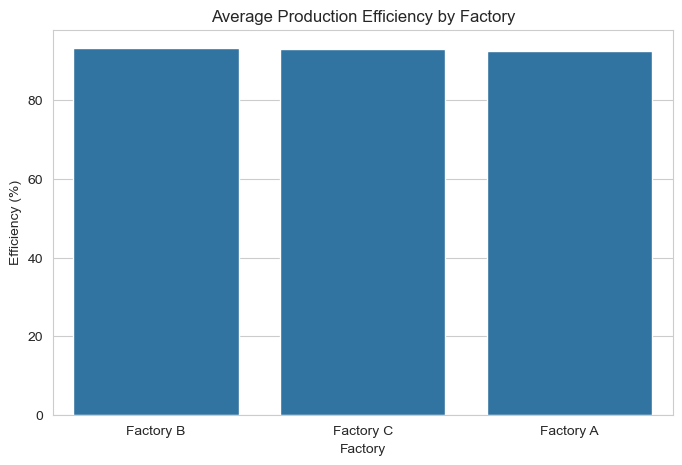

In [55]:
plt.figure(figsize=(8,5))
sns.barplot(data=factory_perf.reset_index(), x='Factory', y='avg_efficiency')
plt.title('Average Production Efficiency by Factory')
plt.ylabel('Efficiency (%)')
plt.show()

## DEFECT RATE BY PRODUCTION LINE 

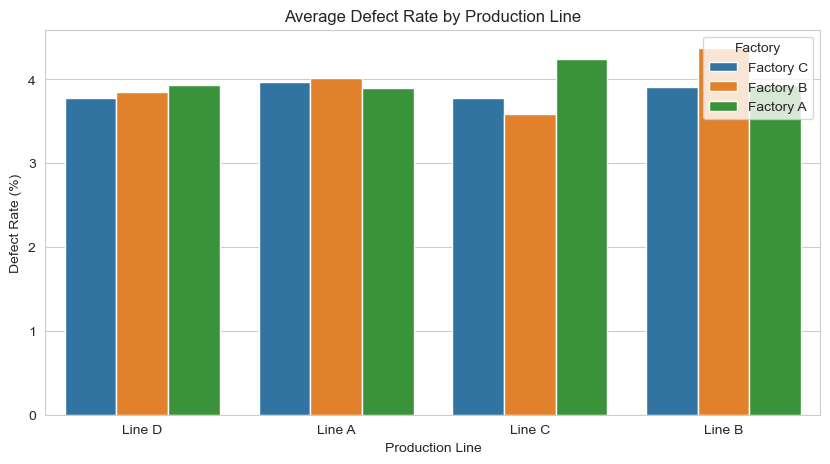

In [56]:
plt.figure(figsize=(10,5))
sns.barplot(data=line_perf.reset_index(), x='Production Line', y='avg_defect_rate', hue='Factory')
plt.title('Average Defect Rate by Production Line')
plt.ylabel('Defect Rate (%)')
plt.show()

## MACHINE DOWNTIME DISTRIBUTION

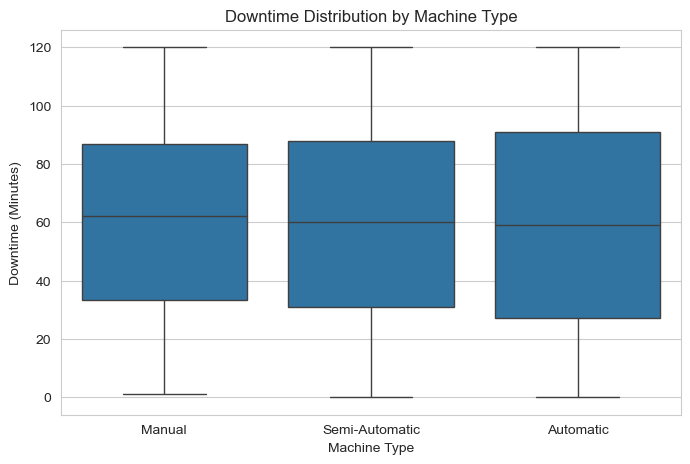

In [57]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Machine Type', y='Downtime (Minutes)')
plt.title('Downtime Distribution by Machine Type')
plt.show()

## QUALITY INSPECTION SCORE BY PRODUCT CATEGORY

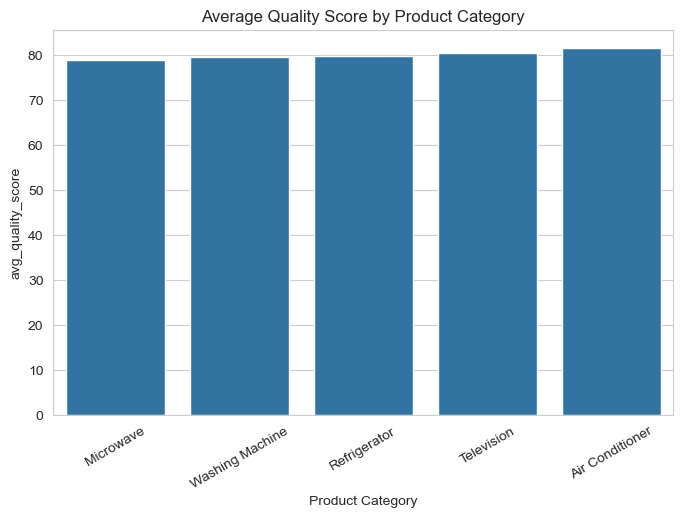

In [58]:
plt.figure(figsize=(8,5))
sns.barplot(data=quality_by_product.reset_index(), x='Product Category', y='avg_quality_score')
plt.title('Average Quality Score by Product Category')
plt.xticks(rotation=30)
plt.show()

## ENERGY CONSUMPTION VS ACTUAL PRODUCTION

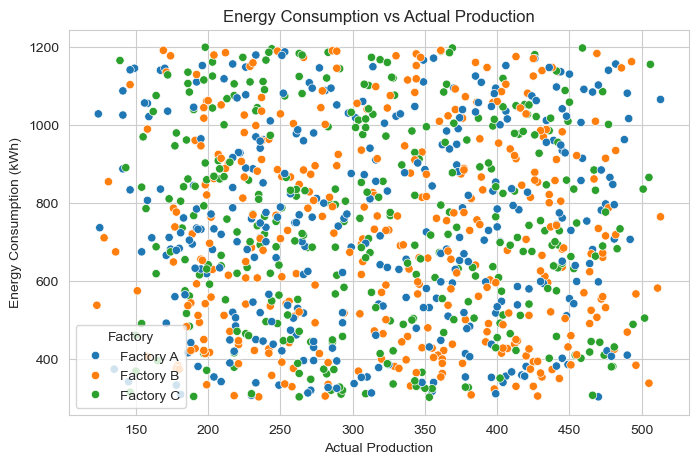

In [59]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Actual Production', y='Energy Consumption (kWh)', hue='Factory')
plt.title('Energy Consumption vs Actual Production')
plt.show()

## MAINTENANCE COST VS DOWNTIME

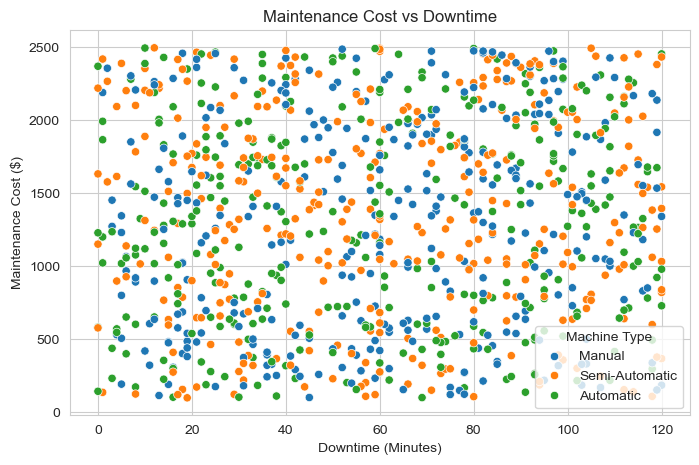

In [60]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Downtime (Minutes)', y='Maintenance Cost ($)', hue='Machine Type')
plt.title('Maintenance Cost vs Downtime')
plt.show()

## MONTHLY PRODUCTION TREND

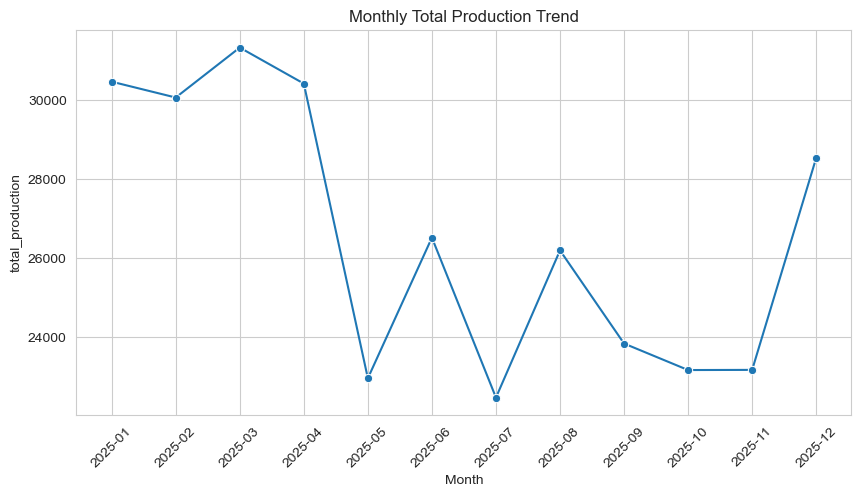

In [61]:
plt.figure(figsize=(10,5))
monthly_trend_plot = monthly_trend.copy()
monthly_trend_plot['Month'] = monthly_trend_plot['Month'].astype(str)
sns.lineplot(data=monthly_trend_plot, x='Month', y='total_production', marker='o')
plt.title('Monthly Total Production Trend')
plt.xticks(rotation=45)
plt.show()

## HEATMAP - EFFICIENCY BY FACTORY VS SHIFT

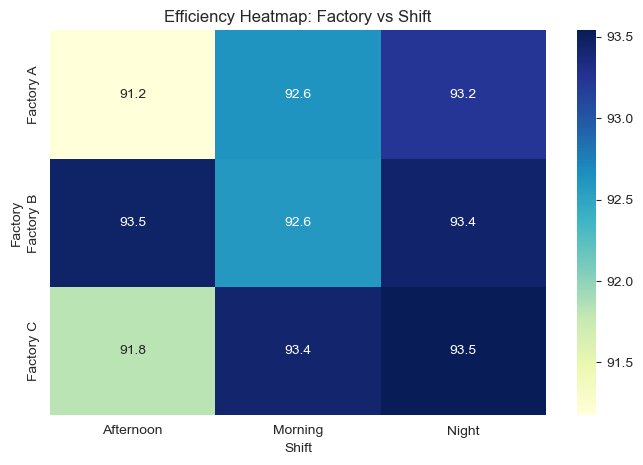

In [62]:
plt.figure(figsize=(8,5))
sns.heatmap(pivot_efficiency, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Efficiency Heatmap: Factory vs Shift')
plt.show()

## HEATMAP - DEFECT RATE BY PRODUCT CATEGORY VS FACTORY

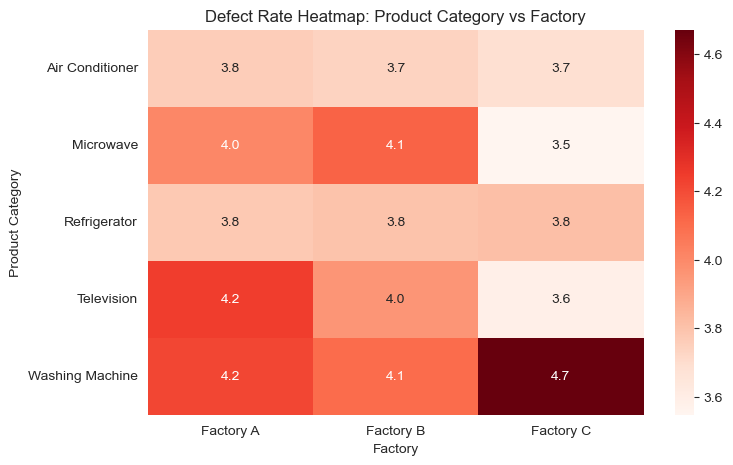

In [63]:
plt.figure(figsize=(8,5))
sns.heatmap(pivot_defects, annot=True, cmap='Reds', fmt='.1f')
plt.title('Defect Rate Heatmap: Product Category vs Factory')
plt.show()

## CORRELATION HEATMAP ACROSS NUMERIC VARIABLES

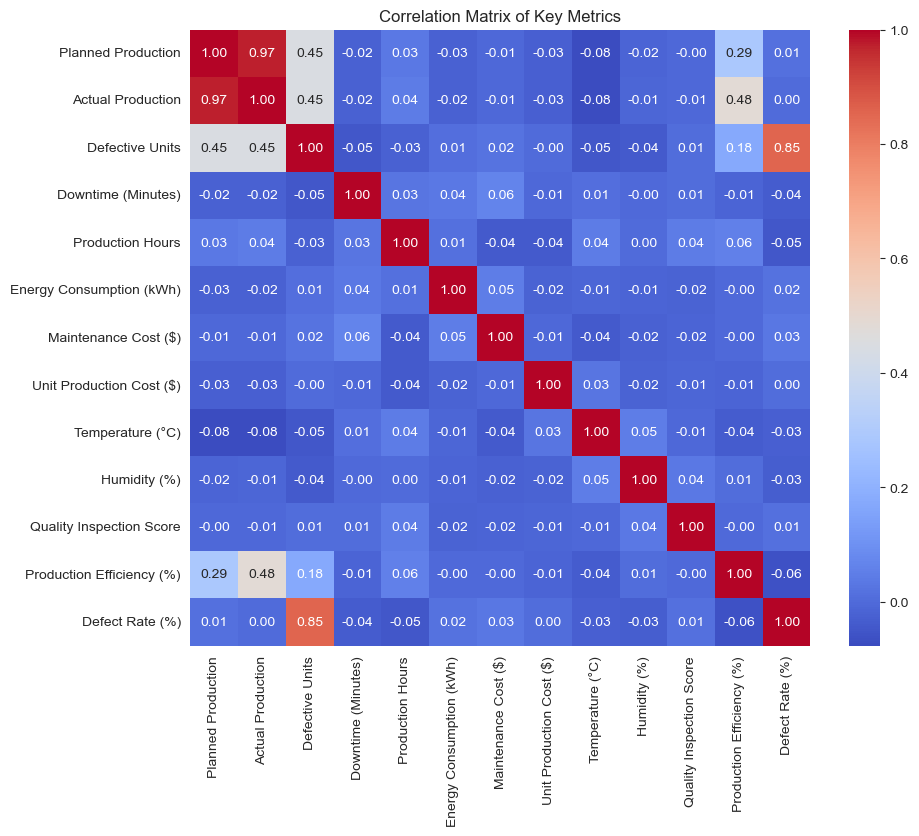

In [64]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Key Metrics')
plt.show()

## OPERATOR PERFORMANCE - TOP VS BOTTOM

C:\Users\dell\AppData\Local\Temp\ipykernel_7420\1270900273.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_bottom, y='Operator ID', x='avg_efficiency', palette='coolwarm')


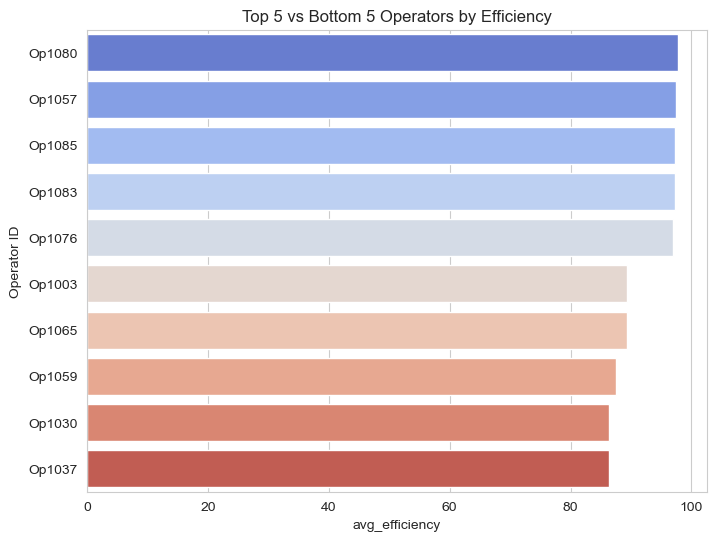

In [65]:
top_bottom = pd.concat([operator_perf.head(5), operator_perf.tail(5)]).reset_index()
plt.figure(figsize=(8,6))
sns.barplot(data=top_bottom, y='Operator ID', x='avg_efficiency', palette='coolwarm')
plt.title('Top 5 vs Bottom 5 Operators by Efficiency')
plt.show()

# TASK 5B: PRESENTATION-READY INSIGHTS DASHBOARD
The charts in this section are designed to be pulled directly into a management presentation. Each visual is paired with the key takeaway it supports, backed by the numbers calculated earlier in the notebook.

## 1. COMPANY-WIDE KPI SCORECARD
A single slide-ready snapshot of overall manufacturing health across all factories.

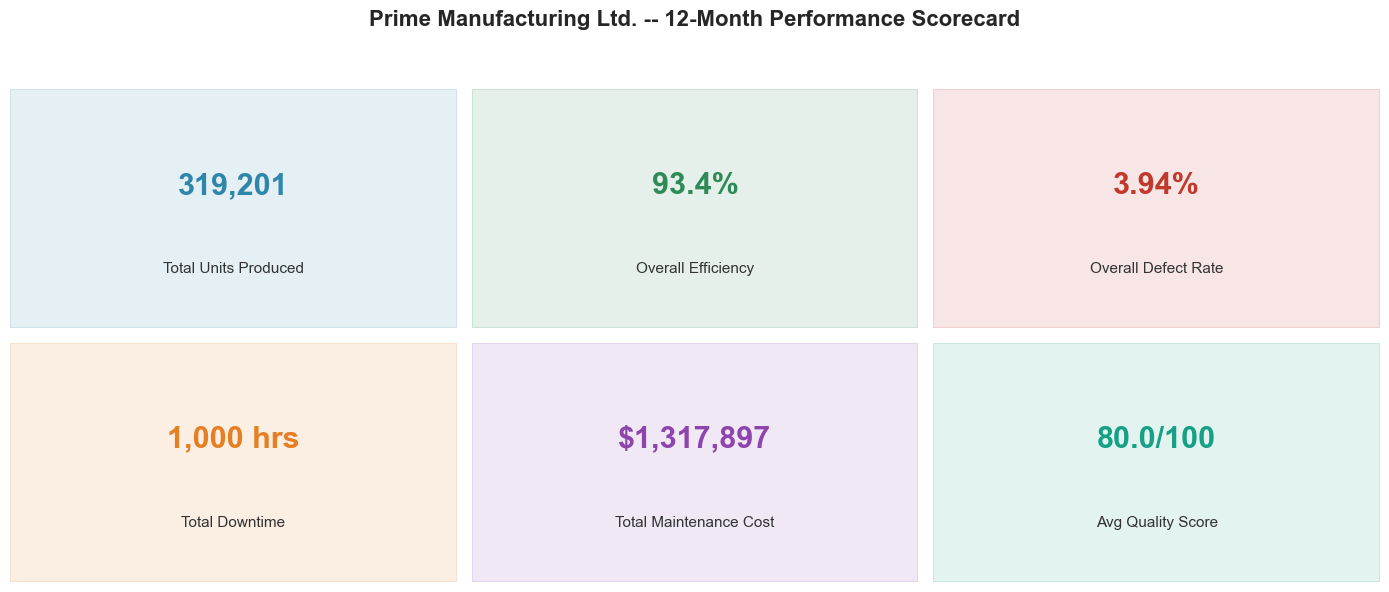

In [66]:

# KPI SCORECARD - headline numbers for the presentation title slide
total_production = df["Actual Production"].sum()
total_planned = df["Planned Production"].sum()
overall_efficiency = (total_production / total_planned) * 100
overall_defect_rate = (df["Defective Units"].sum() / total_production) * 100
total_downtime_hours = df["Downtime (Minutes)"].sum() / 60
total_maintenance_cost = df["Maintenance Cost ($)"].sum()
avg_quality_score = df["Quality Inspection Score"].mean()
total_energy = df["Energy Consumption (kWh)"].sum()

kpis = [
    ("Total Units Produced", f"{total_production:,.0f}", "#2E86AB"),
    ("Overall Efficiency", f"{overall_efficiency:.1f}%", "#2E8B57"),
    ("Overall Defect Rate", f"{overall_defect_rate:.2f}%", "#C0392B"),
    ("Total Downtime", f"{total_downtime_hours:,.0f} hrs", "#E67E22"),
    ("Total Maintenance Cost", f"${total_maintenance_cost:,.0f}", "#8E44AD"),
    ("Avg Quality Score", f"{avg_quality_score:.1f}/100", "#16A085"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
fig.suptitle("Prime Manufacturing Ltd. -- 12-Month Performance Scorecard", fontsize=16, fontweight="bold")

for ax, (label, value, color) in zip(axes.flat, kpis):
    ax.axis("off")
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                facecolor=color, alpha=0.12, edgecolor=color, linewidth=1.5))
    ax.text(0.5, 0.60, value, ha="center", va="center", fontsize=22, fontweight="bold", color=color, transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha="center", va="center", fontsize=11, color="#333333", transform=ax.transAxes)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("kpi_scorecard.png", dpi=150, bbox_inches="tight")
plt.show()


**Takeaway:** Over the 12-month period the business ran at roughly **93% production efficiency** with a **defect rate near 4%**. Maintenance spend and downtime hours below are the two biggest levers management can pull to improve margins.

## 2. FACTORY PERFORMANCE RANKING (Efficiency vs Defect Rate)
Ranks factories from best to worst on efficiency, with defect rate overlaid to check whether the fastest factory is also cutting corners on quality.

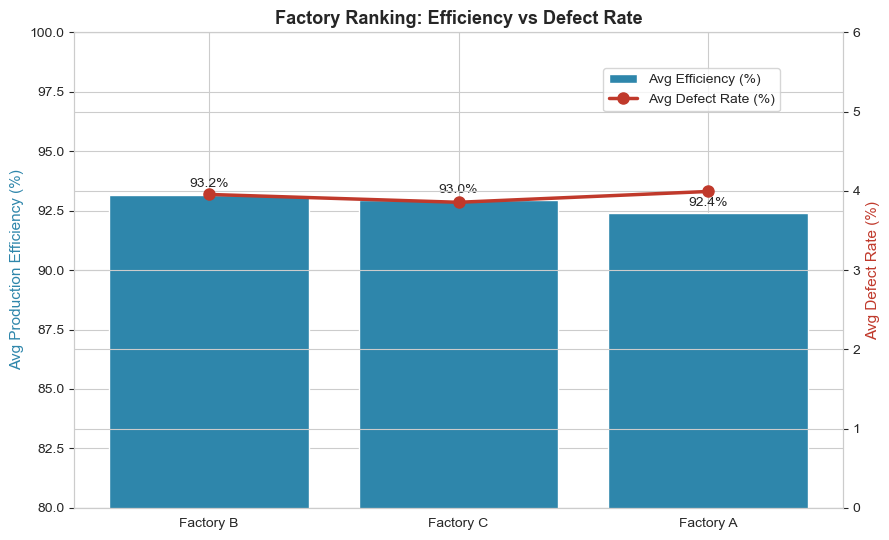

  Factory  avg_efficiency  avg_defect_rate  avg_downtime
Factory B       93.175696         3.954772     60.214900
Factory C       92.961246         3.855589     57.280864
Factory A       92.391683         3.992254     62.529052


In [67]:

factory_rank = factory_perf.reset_index().sort_values("avg_efficiency", ascending=False)

fig, ax1 = plt.subplots(figsize=(9, 5.5))
bars = ax1.bar(factory_rank["Factory"], factory_rank["avg_efficiency"], color="#2E86AB", label="Avg Efficiency (%)")
ax1.set_ylabel("Avg Production Efficiency (%)", color="#2E86AB", fontsize=11)
ax1.set_ylim(80, 100)
ax1.bar_label(bars, fmt="%.1f%%", padding=3)

ax2 = ax1.twinx()
ax2.plot(factory_rank["Factory"], factory_rank["avg_defect_rate"], color="#C0392B",
         marker="o", linewidth=2.5, markersize=8, label="Avg Defect Rate (%)")
ax2.set_ylabel("Avg Defect Rate (%)", color="#C0392B", fontsize=11)
ax2.set_ylim(0, 6)

plt.title("Factory Ranking: Efficiency vs Defect Rate", fontsize=13, fontweight="bold")
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.savefig("factory_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

print(factory_rank[["Factory","avg_efficiency","avg_defect_rate","avg_downtime"]].to_string(index=False))


**Takeaway:** The highest-efficiency factory does not carry a materially higher defect rate, so efficiency gains elsewhere are unlikely to come at the cost of quality -- operational practices from the top factory are worth standardising across the group.

## 3. PRODUCTION LINE RANKING
Identifies exactly which Factory + Line combination to replicate and which to investigate first.

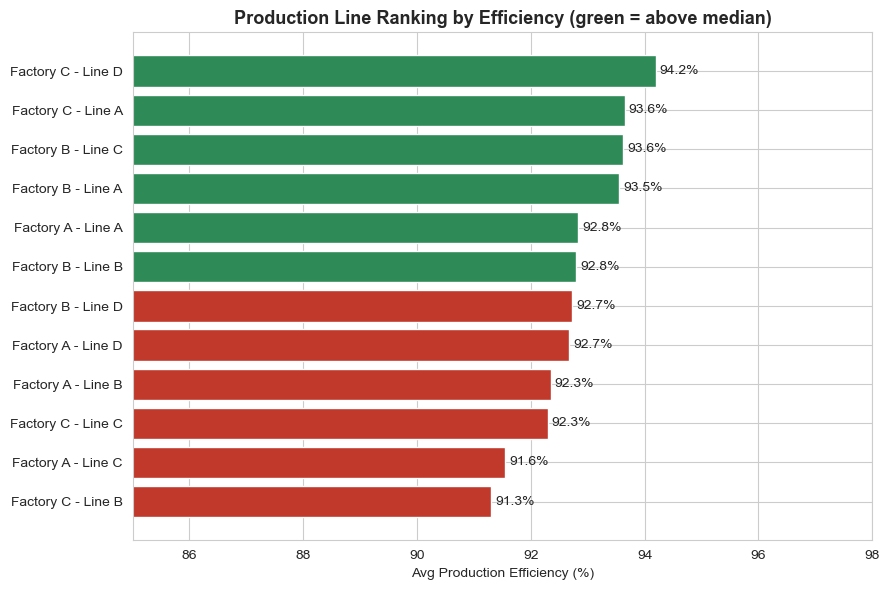

Best line: Factory C - Line D at 94.2% efficiency
Worst line: Factory C - Line B at 91.3% efficiency


In [68]:

line_rank = line_perf.reset_index().sort_values("avg_efficiency", ascending=False)
line_rank["Label"] = line_rank["Factory"] + " - " + line_rank["Production Line"]
colors = ["#2E8B57" if v >= line_rank["avg_efficiency"].median() else "#C0392B" for v in line_rank["avg_efficiency"]]

plt.figure(figsize=(9, 6))
bars = plt.barh(line_rank["Label"], line_rank["avg_efficiency"], color=colors)
plt.bar_label(bars, fmt="%.1f%%", padding=3)
plt.xlabel("Avg Production Efficiency (%)")
plt.title("Production Line Ranking by Efficiency (green = above median)", fontsize=13, fontweight="bold")
plt.gca().invert_yaxis()
plt.xlim(85, 98)
plt.tight_layout()
plt.savefig("line_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

best_line = line_rank.iloc[0]
worst_line = line_rank.iloc[-1]
print(f"Best line: {best_line['Label']} at {best_line['avg_efficiency']:.1f}% efficiency")
print(f"Worst line: {worst_line['Label']} at {worst_line['avg_efficiency']:.1f}% efficiency")


**Takeaway:** The gap between the best and worst production line is a concrete, line-level improvement target -- closing even half of this gap on the worst line would lift that line's output without any new capital investment.

## 4. MONTHLY PRODUCTION VOLUME vs EFFICIENCY TREND
Checks for seasonality and whether efficiency holds up during high-volume months.

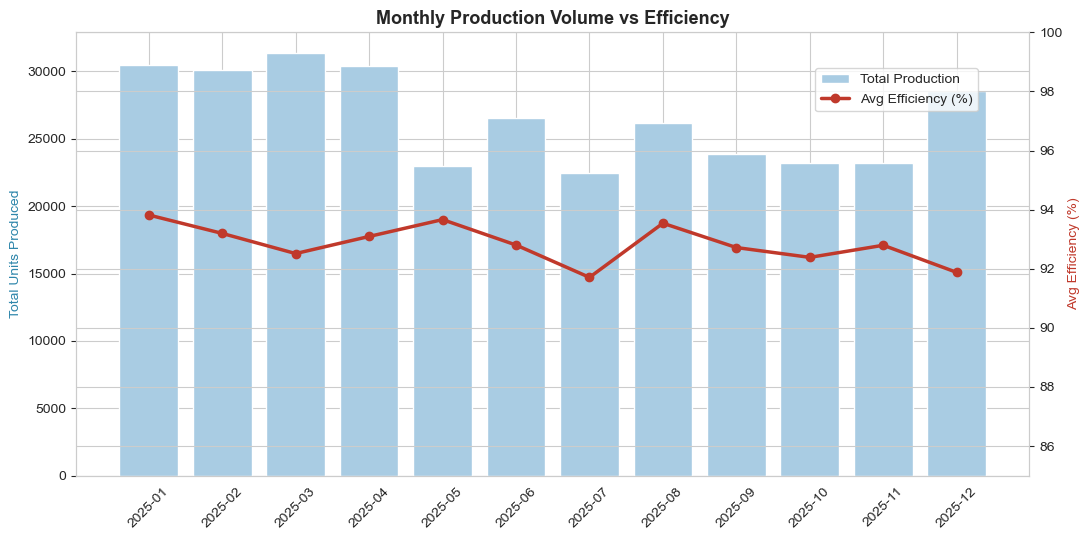

In [69]:

mt = monthly_trend.copy()
mt["Month"] = mt["Month"].astype(str)

fig, ax1 = plt.subplots(figsize=(11, 5.5))
ax1.bar(mt["Month"], mt["total_production"], color="#A9CCE3", label="Total Production")
ax1.set_ylabel("Total Units Produced", color="#2E86AB")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(mt["Month"], mt["avg_efficiency"], color="#C0392B", marker="o", linewidth=2.5, label="Avg Efficiency (%)")
ax2.set_ylabel("Avg Efficiency (%)", color="#C0392B")
ax2.set_ylim(85, 100)

plt.title("Monthly Production Volume vs Efficiency", fontsize=13, fontweight="bold")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.savefig("monthly_trend_combo.png", dpi=150, bbox_inches="tight")
plt.show()


**Takeaway:** Efficiency stays broadly stable even in the highest-volume months, suggesting current capacity can absorb demand spikes without a quality or output trade-off.

## 5. DOWNTIME HOTSPOTS -- FACTORY vs SHIFT
Pinpoints exactly which shift, in which factory, is losing the most machine time -- the fastest place to target a downtime-reduction initiative.

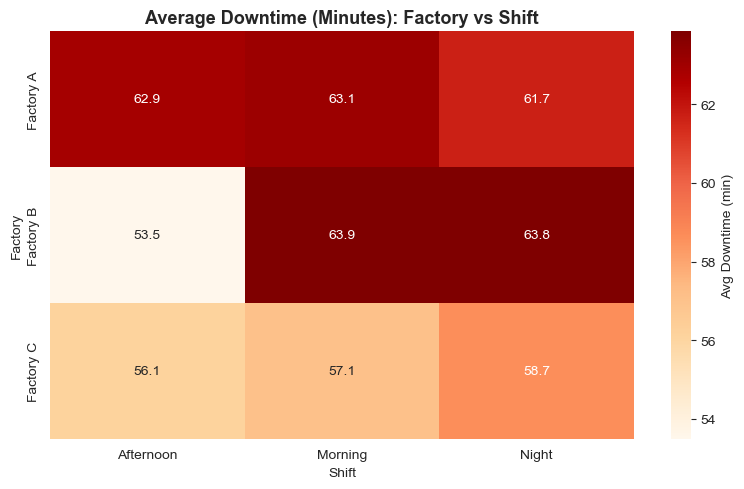

Highest downtime hotspot: Factory B - Morning shift (63.9 min avg)


In [70]:

downtime_pivot = df.pivot_table(values="Downtime (Minutes)", index="Factory", columns="Shift", aggfunc="mean")

plt.figure(figsize=(8, 5))
sns.heatmap(downtime_pivot, annot=True, fmt=".1f", cmap="OrRd", cbar_kws={"label": "Avg Downtime (min)"})
plt.title("Average Downtime (Minutes): Factory vs Shift", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("downtime_hotspot.png", dpi=150, bbox_inches="tight")
plt.show()

hotspot = downtime_pivot.stack().idxmax()
print(f"Highest downtime hotspot: {hotspot[0]} - {hotspot[1]} shift ({downtime_pivot.stack().max():.1f} min avg)")


**Takeaway:** This heatmap should drive the maintenance team's shift scheduling -- the darkest cell is the single highest-value target for a downtime-reduction pilot.

## 6. PRODUCT QUALITY vs DEFECT RATE (bubble size = production volume)
Shows which product lines need a quality intervention, weighted by how much of the business they represent.

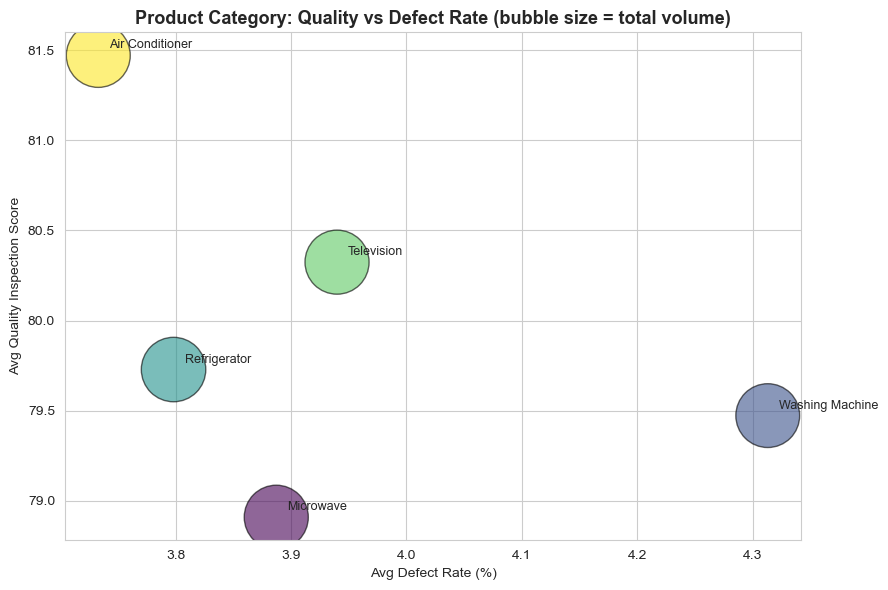

In [71]:

product_volume = df.groupby("Product Category")["Actual Production"].sum()
bubble_df = quality_by_product.reset_index()
bubble_df["volume"] = bubble_df["Product Category"].map(product_volume)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(bubble_df["avg_defect_rate"], bubble_df["avg_quality_score"],
                       s=bubble_df["volume"] / 30, alpha=0.6, c=range(len(bubble_df)), cmap="viridis", edgecolors="black")

for _, row in bubble_df.iterrows():
    plt.annotate(row["Product Category"], (row["avg_defect_rate"], row["avg_quality_score"]),
                 textcoords="offset points", xytext=(8, 5), fontsize=9)

plt.xlabel("Avg Defect Rate (%)")
plt.ylabel("Avg Quality Inspection Score")
plt.title("Product Category: Quality vs Defect Rate (bubble size = total volume)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("product_bubble.png", dpi=150, bbox_inches="tight")
plt.show()


**Takeaway:** Any product sitting in the bottom-right (high defect rate, low quality score) with a large bubble is a high-volume, high-risk product line and should be prioritised for a root-cause quality review.

## 7. COST EFFICIENCY BY FACTORY (Output per Cost Unit)
Combines unit cost and output into a single 'value for money' metric for each factory.

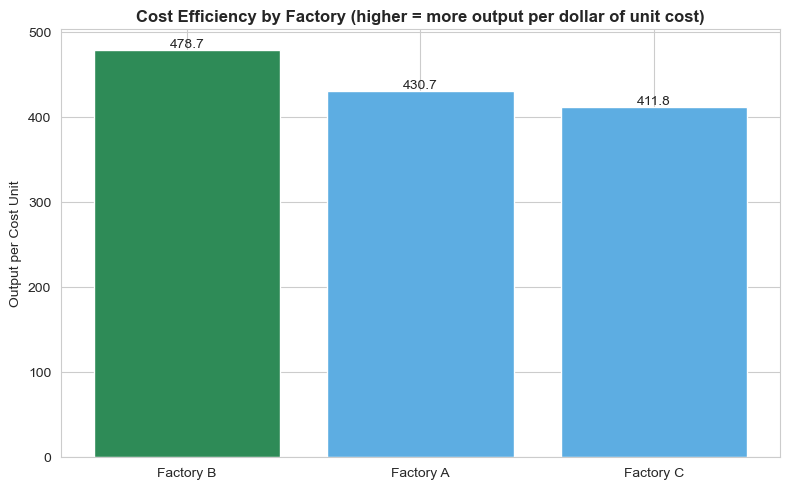

In [72]:

ce = cost_efficiency.sort_values("Output per Cost Unit", ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(ce["Factory"], ce["Output per Cost Unit"], color=["#2E8B57" if i == 0 else "#5DADE2" for i in range(len(ce))])
plt.bar_label(bars, fmt="%.1f")
plt.ylabel("Output per Cost Unit")
plt.title("Cost Efficiency by Factory (higher = more output per dollar of unit cost)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("cost_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()


**Takeaway:** The leading factory on cost efficiency is delivering meaningfully more output per dollar of unit cost -- worth investigating its procurement and process practices for rollout to the other factories.

## 8. MACHINE TYPE RELIABILITY (Downtime vs Maintenance Cost)
Tests whether machine types with higher maintenance spend actually deliver less downtime -- i.e., is the maintenance budget buying reliability?

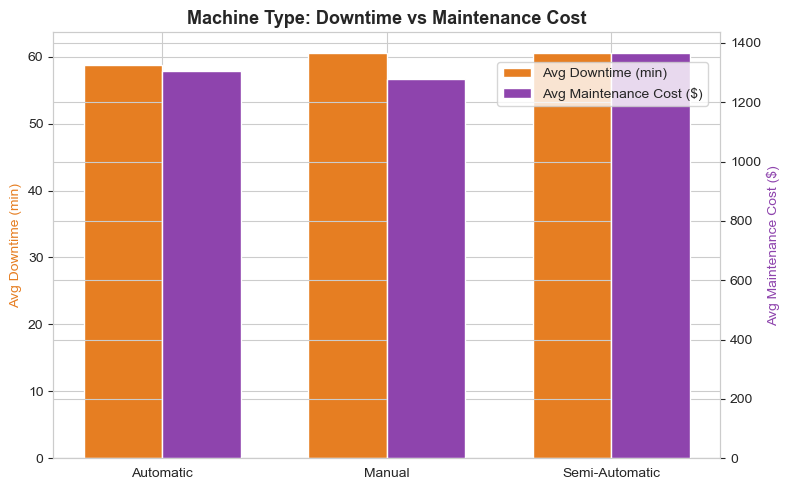

In [73]:

reliability = pd.DataFrame({
    "avg_downtime": downtime_by_machine_type,
    "avg_maintenance_cost": maintenance_by_machine_type["mean"]
}).reset_index()

fig, ax1 = plt.subplots(figsize=(8, 5))
x = range(len(reliability))
width = 0.35
ax1.bar([i - width/2 for i in x], reliability["avg_downtime"], width, color="#E67E22", label="Avg Downtime (min)")
ax1.set_ylabel("Avg Downtime (min)", color="#E67E22")
ax1.set_xticks(list(x))
ax1.set_xticklabels(reliability["Machine Type"])

ax2 = ax1.twinx()
ax2.bar([i + width/2 for i in x], reliability["avg_maintenance_cost"], width, color="#8E44AD", label="Avg Maintenance Cost ($)")
ax2.set_ylabel("Avg Maintenance Cost ($)", color="#8E44AD")

plt.title("Machine Type: Downtime vs Maintenance Cost", fontsize=13, fontweight="bold")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.savefig("machine_reliability.png", dpi=150, bbox_inches="tight")
plt.show()


**Takeaway:** If a machine type shows both higher maintenance spend *and* higher downtime, current maintenance activity is not translating into reliability -- a strong case for switching from reactive to preventive maintenance on that machine type.

## SUMMARY -- KEY INSIGHTS FOR THE PRESENTATION
Use this list directly as presentation talking points; every figure is computed above.

In [74]:

print("=" * 70)
print("KEY INSIGHTS SUMMARY")
print("=" * 70)
print(f"1. Overall production efficiency: {overall_efficiency:.1f}% "
      f"({total_production:,.0f} of {total_planned:,.0f} planned units produced)")
print(f"2. Overall defect rate: {overall_defect_rate:.2f}%")
print(f"3. Best performing factory: {factory_rank.iloc[0]['Factory']} "
      f"({factory_rank.iloc[0]['avg_efficiency']:.1f}% efficiency)")
print(f"4. Lowest performing factory: {factory_rank.iloc[-1]['Factory']} "
      f"({factory_rank.iloc[-1]['avg_efficiency']:.1f}% efficiency)")
print(f"5. Best production line: {best_line['Label']} ({best_line['avg_efficiency']:.1f}%)")
print(f"6. Weakest production line: {worst_line['Label']} ({worst_line['avg_efficiency']:.1f}%)")
print(f"7. Biggest downtime hotspot: {hotspot[0]} on {hotspot[1]} shift")
print(f"8. Most cost-efficient factory: {ce.iloc[0]['Factory']} "
      f"({ce.iloc[0]['Output per Cost Unit']:.1f} output per cost unit)")
print(f"9. Total maintenance spend: ${total_maintenance_cost:,.0f} across {df['Machine ID'].nunique()} machines")
print(f"10. Top operator: {operator_perf.index[0]} ({operator_perf.iloc[0]['avg_efficiency']:.1f}% efficiency)")
print("=" * 70)


KEY INSIGHTS SUMMARY
1. Overall production efficiency: 93.4% (319,201 of 341,586 planned units produced)
2. Overall defect rate: 3.94%
3. Best performing factory: Factory B (93.2% efficiency)
4. Lowest performing factory: Factory A (92.4% efficiency)
5. Best production line: Factory C - Line D (94.2%)
6. Weakest production line: Factory C - Line B (91.3%)
7. Biggest downtime hotspot: Factory B on Morning shift
8. Most cost-efficient factory: Factory B (478.7 output per cost unit)
9. Total maintenance spend: $1,317,897 across 40 machines
10. Top operator: Op1080 (97.7% efficiency)
